In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_agent_based import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

from graphs import plot_model, plot_wage_gap, plot_mean_age_high_skill

import copy


model = ModelClass()

In [4]:
model.allocate()

(array([5.6300e+02, 7.8450e+03, 2.5873e+04, 4.6912e+04, 6.0675e+04,
        6.6229e+04, 6.5014e+04, 5.9738e+04, 5.2337e+04, 4.4271e+04,
        3.6805e+04, 2.9995e+04, 2.4313e+04, 1.9761e+04, 1.5863e+04,
        1.2698e+04, 9.9970e+03, 8.0210e+03, 6.4920e+03, 5.1460e+03,
        4.1470e+03, 3.3620e+03, 2.5990e+03, 2.1320e+03, 1.6740e+03,
        1.3250e+03, 1.1180e+03, 9.2400e+02, 7.4100e+02, 5.7000e+02,
        5.0300e+02, 4.0000e+02, 3.0900e+02, 2.7700e+02, 2.2200e+02,
        1.9400e+02, 1.6600e+02, 1.2500e+02, 9.7000e+01, 7.1000e+01,
        6.8000e+01, 7.9000e+01, 5.5000e+01, 4.0000e+01, 4.0000e+01,
        2.4000e+01, 2.8000e+01, 2.1000e+01, 2.1000e+01, 1.2000e+01,
        1.0000e+01, 1.2000e+01, 1.0000e+01, 1.2000e+01, 1.8000e+01,
        5.0000e+00, 5.0000e+00, 7.0000e+00, 5.0000e+00, 3.0000e+00,
        2.0000e+00, 1.0000e+00, 0.0000e+00, 3.0000e+00, 4.0000e+00,
        2.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.0000e+00,
        0.0000e+00, 0.0000e+00, 1.0000e+00, 1.00

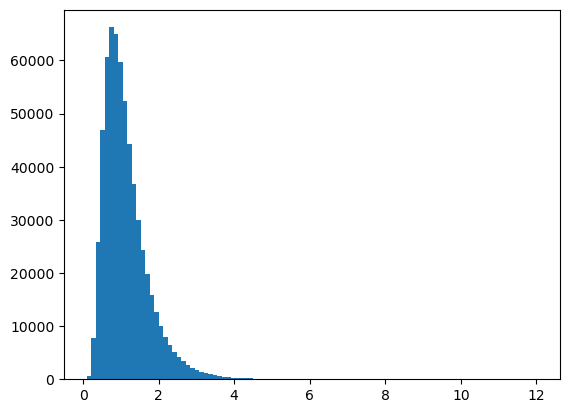

In [11]:
plt.hist(model.sol.ability_draws, bins=100)

In [12]:

from statistics import NormalDist


def create_weighted_lognormal_distribution(mean, sigma, n_obs, total_mass=1.0):
    """Approximate a lognormal distribution by equiprobable weighted points."""

    if n_obs < 1:
        raise ValueError("n_obs must be at least 1")

    if sigma < 0:
        raise ValueError("sigma must be non-negative")

    weights = np.full(n_obs, total_mass / n_obs)

    if sigma == 0:
        return np.full(n_obs, np.exp(mean)), weights

    normal_dist = NormalDist(mu=mean, sigma=sigma)
    probabilities = (np.arange(n_obs) + 0.5) / n_obs
    abilities = np.exp(np.array([normal_dist.inv_cdf(p) for p in probabilities]))

    return abilities, weights

(array([7.60842756e-03, 1.06017965e-01, 3.49649816e-01, 6.33972564e-01,
        8.19966860e-01, 8.95024066e-01, 8.78604457e-01, 8.07304166e-01,
        7.07286453e-01, 5.98281877e-01, 4.97385749e-01, 4.05354857e-01,
        3.28567850e-01, 2.67051753e-01, 2.14373866e-01, 1.71601800e-01,
        1.35100267e-01, 1.08396443e-01, 8.77334134e-02, 6.95434604e-02,
        5.60428936e-02, 4.54343401e-02, 3.51230963e-02, 2.88120205e-02,
        2.26225715e-02, 1.79061572e-02, 1.51087425e-02, 1.24870108e-02,
        1.00139340e-02, 7.70302613e-03, 6.79758271e-03, 5.40563237e-03,
        4.17585101e-03, 3.74340042e-03, 3.00012597e-03, 2.62173170e-03,
        2.24333743e-03, 1.68926012e-03, 1.31086585e-03, 9.59499746e-04,
        9.18957503e-04, 1.06761239e-03, 7.43274451e-04, 5.40563237e-04,
        5.40563237e-04, 3.24337942e-04, 3.78394266e-04, 2.83795699e-04,
        2.83795699e-04, 1.62168971e-04, 1.35140809e-04, 1.62168971e-04,
        1.35140809e-04, 1.62168971e-04, 2.43253457e-04, 6.757040

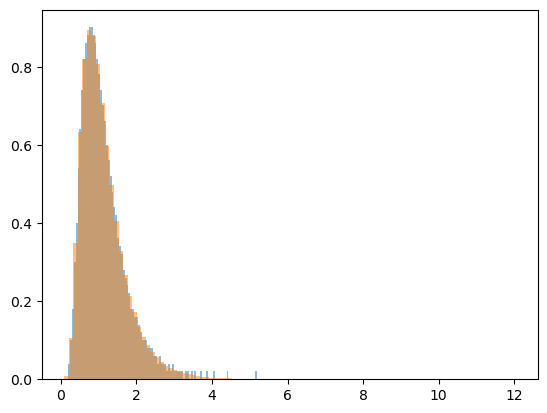

In [48]:
log_normal_dist = create_weighted_lognormal_distribution(model.par.theta_mean, model.par.theta_std, 1000, total_mass=20_000)

plt.hist(log_normal_dist[0], bins=100, weights=log_normal_dist[1]*31, density=True, alpha=0.5)
plt.hist(model.sol.ability_draws, bins=100, density=True, alpha=0.5)

In [ ]:
import pandas as pd
import numpy as np

transition_matrix = pd.read_csv('Data/transition_matrix_all.csv', header=0, index_col=0)

survival_rates = transition_matrix.loc[:, transition_matrix.columns.str.startswith('survival_rate')]

survival_rates = np.vstack([survival_rates.values, np.zeros((1, survival_rates.shape[1]))])

np.savetxt('Exogenous_estimation/survival_rates.csv', survival_rates, delimiter=',')

In [ ]:
ss_distribution = transition_matrix.loc[:, "n_obs1990"]

ss_distribution = np.append(ss_distribution.values, [0])

ss_transition = ss_distribution[1:] / ss_distribution[:-1]

np.savetxt('Exogenous_estimation/ss_transition.csv', ss_transition, delimiter=',')

np.savetxt('Exogenous_estimation/ss_distribution.csv', ss_distribution, delimiter=',')

array([1.00700199, 1.01584836, 0.9688524 , 0.98399128, 1.00385724,
       0.97704057, 1.00070088, 0.99566148, 1.01105966, 0.97736892,
       0.98651428, 1.01006214, 0.96779251, 0.98056142, 1.02981954,
       0.99250716, 1.04615573, 1.05669418, 1.02739067, 0.95972115,
       0.93299172, 0.90830265, 0.91977674, 0.87552677, 0.95888113,
       0.94257522, 0.96905146, 0.92968848, 0.94261105, 0.94542392,
       0.93567828, 0.92437009, 0.94149612, 0.94614597, 0.70034929,
       0.79790672, 0.81758958, 0.76666308, 0.80505618, 0.73604327,
       0.78881251, 0.5141226 , 0.59380479, 0.83169291, 0.34319527,
       0.53793103, 0.77564103, 0.84297521, 0.69607843, 0.        ])

In [7]:
import pandas as pd
import numpy as np

N_1 = 5000
n = 50

T_max = 1000

max_capacity = int(N_1 * n * 1.1)

age = np.full((max_capacity, T_max), np.nan)
wage = np.full((max_capacity, T_max), np.nan)

age_init = np.repeat(np.arange(0, n, 1), N_1)
wage_init = np.repeat(np.ones((1, n)), N_1)

age[:N_1*n, 0] = age_init
wage[:N_1*n, 0] = wage_init

x = np.linspace(1.0, n, n)
rho_shape = 5.0
rho = -((x / n) ** rho_shape) + 1

for t in range(T_max - 1):
    pop_size = np.sum(~np.isnan(age[:, t]))

    surviving = np.random.rand(pop_size) < rho[age[:pop_size, t].astype(int)]

    surviving_cohort = age[:pop_size, t][surviving] + 1
    new_cohort = np.zeros(N_1, dtype=int)

    next_period_pop = np.hstack([new_cohort, surviving_cohort])

    age[:len(next_period_pop), t + 1] = next_period_pop

age

array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ...,  0.,  0.,  0.],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]])

In [2]:
# Count non-nan in age
import matplotlib.pyplot as plt

non_nan = np.sum(~np.isnan(age), axis=0)
plt.plot(non_nan)

NameError: name 'np' is not defined

In [68]:
np.random.lognormal(0, 1, 1000)

array([3.27269478e-01, 1.35281484e+00, 2.55796928e-01, 8.50552203e+00,
       3.22698811e-01, 3.83921993e-01, 5.64563990e-01, 3.28793276e-01,
       3.67101771e+00, 3.02743002e-01, 4.39469906e-01, 2.83706562e+00,
       1.28023732e+00, 1.06020100e+01, 1.14785865e+00, 6.08764422e+00,
       1.20900980e-01, 1.28891541e+00, 3.62608965e+00, 3.57218344e-01,
       2.43255475e+00, 5.37774029e-01, 2.64828876e+00, 7.57020881e-01,
       2.14067276e-01, 2.53213470e+00, 1.08869966e+00, 7.75219852e-01,
       5.54176517e-01, 8.67654478e-01, 4.19761696e+00, 1.10250311e+00,
       3.08721110e+00, 3.79004602e+00, 3.13455830e+00, 5.57442453e-01,
       7.61516904e-01, 5.82019718e-01, 1.78691370e+00, 9.49854709e-01,
       6.22989722e-01, 1.10644437e+00, 1.31410017e+00, 3.81218914e-01,
       1.98974770e+00, 1.26398963e+00, 3.11095641e-01, 6.13388785e-01,
       1.91927433e+00, 1.49291708e-01, 1.28241373e+00, 2.90785266e-01,
       5.09751556e+00, 1.04768150e+00, 4.80837145e+00, 1.44901742e+00,
      

(array([  2.,   1.,   7.,  10.,   7.,  23.,  26.,  49.,  51.,  80., 103.,
        139., 205., 223., 269., 327., 379., 445., 473., 568., 589., 650.,
        616., 579., 524., 543., 495., 494., 438., 334., 293., 236., 201.,
        164., 118., 115.,  65.,  56.,  36.,  24.,  13.,  13.,   4.,   5.,
          2.,   3.,   1.,   0.,   0.,   2.]),
 array([4.38304539e-05, 4.38991344e-05, 4.39678149e-05, 4.40364954e-05,
        4.41051760e-05, 4.41738565e-05, 4.42425370e-05, 4.43112175e-05,
        4.43798981e-05, 4.44485786e-05, 4.45172591e-05, 4.45859396e-05,
        4.46546202e-05, 4.47233007e-05, 4.47919812e-05, 4.48606617e-05,
        4.49293423e-05, 4.49980228e-05, 4.50667033e-05, 4.51353838e-05,
        4.52040644e-05, 4.52727449e-05, 4.53414254e-05, 4.54101059e-05,
        4.54787865e-05, 4.55474670e-05, 4.56161475e-05, 4.56848280e-05,
        4.57535086e-05, 4.58221891e-05, 4.58908696e-05, 4.59595501e-05,
        4.60282307e-05, 4.60969112e-05, 4.61655917e-05, 4.62342722e-05,
        4.

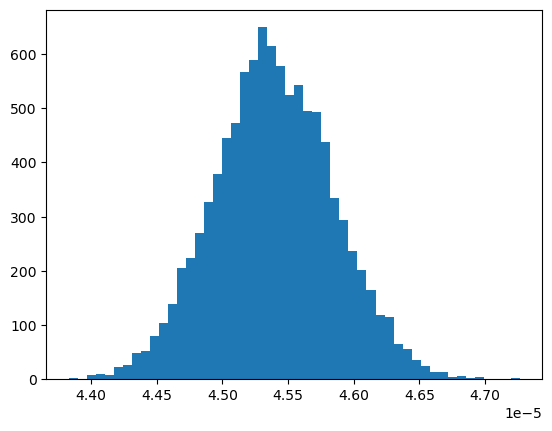

In [8]:
import matplotlib.pyplot as plt
import numpy as np

plt.hist(np.random.lognormal(-10, 0.01, 10000), bins=50)

250000

In [6]:
import pandas as pd
import numpy as np

N_1 = 5000
n = 50

T_max = 1000

wage = np.full((N_1, n, T_max), np.nan)

wage[:, :, 0] = np.ones((N_1, n))

x = np.linspace(1.0, n, n)
rho_shape = 5.0
rho = -((x / n) ** rho_shape) + 1

for t in range(T_max - 1):

    surviving = np.random.rand(pop_size) < rho[age[:pop_size, t].astype(int)]

    surviving_cohort = age[:pop_size, t][surviving] + 1
    new_cohort = np.zeros(N_1, dtype=int)

    next_period_pop = np.hstack([new_cohort, surviving_cohort])

    age[:len(next_period_pop), t + 1] = next_period_pop

age

NameError: name 'pop_size' is not defined

In [5]:
import pandas as pd
import numpy as np

N_1 = 5000
n = 50

T_max = 1000

wage = np.full((N_1, n, T_max), np.nan)

wage[:, :, 0] = np.ones((N_1, n))


wage.shape

(5000, 50, 1000)

In [ ]:
np.repeat(50, N_1)

array([50, 50, 50, ..., 50, 50, 50])

In [78]:
a = np.array([1, 2, 3, 4, 5, 6])
b = np.array([5, 2, 3, 5, 6, 7])

idx = np.argsort(b)[::-1]   # indices that sort b descending

a_sorted = a[idx]
b_sorted = b[idx]

print(a_sorted)
print(b_sorted)

[6 5 4 1 3 2]
[7 6 5 5 3 2]


In [79]:
idx

array([5, 4, 3, 0, 2, 1], dtype=int64)